# Imports



In [74]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gp

class Dirs:
    def __init__(self):
        self.home = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS"
        self.images = os.path.join(self.home, 'images')
        self.data = os.path.join(self.home, 'data')
        self.geo = os.path.join(self.data, 'Geotiff')
        
dirs = Dirs()



# Stroming langs het schip (retourstroom, sinkage, draft)

Verband tussen retourstroom snelheid van het schip en de sinkage:

$$ v = - V_s + \sqrt{V_s^2 + 2 g \Delta h}$$


In [10]:
def vRet(Vs, dh):
    """Return the returnflow [m/s].
    
    Parameters
    ----------
    Vs: float
        Ship velocity
    dh: float
        Ship sinkage
    """
    g = 9.81
    return -Vs + np.sqrt(Vs ** 2 + 2 * g * dh) 

# Gegevens van enkele sheepspassages met een fraaie sinkage curve

De laatste 4 zijn een focus op M12 schepen.

Ik heb van alle schepen in het rapport van Femke er twaalf gekozen en de data uit de grafieken gehaald.

In [11]:
# Scheeps data uit de grafieken van het rapport van Femke (2025) met de resulaten van de metingen met het meetframe op de bodem van het ARK bij Nigtevegt (11-20 juni 2025.)
    
    # datetime         ship type, 'color', 'vs', 'vr', 'dh', 'draft', 'SNR', 'SNR0']
data = [        
    ['2025-07-11 14:15:26',  'M8', 'b', 4.0, 0.6011, -0.2223, 3.2, 43.6, 33.8],
    ['2025-07-11 14:35:55', 'M12', 'r', 3.7, 0.8339, -0.2721, 3.5, 49.4, 35.3],
    ['2025-07-11 15:13:54',  'M8', 'b', 4.4, 0.5945, -0.1864, 2.7, 44.2, 35.3],    
    ['2025-07-11 17:25:58',  'M8', 'b', 4.1, 0.6107, -0.2515, 2.8, 46.0, 32.3],
    ['2025-07-11 18:35:15',  'M9', 'g', 4.5, 0.4422, -0.1785, 2.7, 42.6, 33.0],
    ['2025-07-11 19:28:21', 'C31', 'b', 3.7, 0.5745, -0.2482, 3.7, 46.0, 33.2],
    ['2025-07-11 20:04:30',  'M8', 'b', 4.6, 0.4967, -0.2425, 2.0, 43.9, 31.8],
    ['2025-07-11 21:31:24',  'M8', 'b', 4.6, 0.6907, -0.2557, 2.9, 44.0, 33.5],
    ['2025-07-11 23:53:42',  'M8', 'b', 4.3, 0.4800, -0.2256, 2.7, 41.5, 32.9],    
    ['2025-07-12 02:08:50',  'M8', 'b', 3.3, 0.7311, -0.3055, 3.5, 47.0, 31.5],
    ['2025-07-12 02:58:27', 'M12', 'r', 3.3, 1.0677, -0.4246, 3.8, 49.5, 32.0],
    ['2025-07-12 03:29:32',  'M8', 'b', 4.9, 0.7291, -0.2940, 2.8, 47.4, 36.6],
    ['2025-07-12 03:37:37',  'M8', 'b', 3.9, 0.7804, -0.3054, 3.5, 47.0, 36.1],
    ['2025-07-12 12:03:42',  'M6', 'c', 4.1, 0.6240, -0.2813, 3.0, 43.4, 33.4],
    ['2025-07-13 13:14:16', 'M12', 'r', 3.3, 0.8828, -0.3190, 4.0, 48.0, 33.8],
    ['2025-07-13 16:23:06', 'M12', 'r', 3.5, 0.7388, -0.2364, 3.3, 48.5, 32.2],
    ['2025-07-13 18:07:19', 'M12', 'r', 3.2, 0.8274, -0.3453, 3.4, 47.8, 34.8],
    ['2025-07-13 21:15:57', 'M12', 'r', 3.4, 0.7903, -0.3350, 3.3, 47.5, 32.9],
]
ships = pd.DataFrame(data=data, columns=['datetime', 'type', 'color', 'vs', 'vr', 'dh', 'draft', 'SNR', 'SNR0'])
ships=ships.astype(dict(datetime='datetime64[ns]', vs=float, vr=float, dh=float, draft=float, SNR=float, SNR0=float))

ships['vr2'] = vRet(ships['vs'], -ships['dh'])
ships['dSNR'] = ships['SNR'] - ships['SNR0']

ships

,datetime,type,color,vs,vr,dh,draft,SNR,SNR0,vr2,dSNR
0,2025-07-11 14:15:26,M8,b,4.0,0.6011,-0.2223,3.2,43.6,33.8,0.512375,9.8
1,2025-07-11 14:35:55,M12,r,3.7,0.8339,-0.2721,3.5,49.4,35.3,0.662179,14.1
2,2025-07-11 15:13:54,M8,b,4.4,0.5945,-0.1864,2.7,44.2,35.3,0.397621,8.9
3,2025-07-11 17:25:58,M8,b,4.1,0.6107,-0.2515,2.8,46.0,32.3,0.563092,13.7
4,2025-07-11 18:35:15,M9,g,4.5,0.4422,-0.1785,2.7,42.6,33.0,0.373620,9.6
5,2025-07-11 19:28:21,C31,b,3.7,0.5745,-0.2482,3.7,46.0,33.2,0.608095,12.8
6,2025-07-11 20:04:30,M8,b,4.6,0.4967,-0.2425,2.0,43.9,31.8,0.490958,12.1
7,2025-07-11 21:31:24,M8,b,4.6,0.6907,-0.2557,2.9,44.0,33.5,0.516330,10.5
8,2025-07-11 23:53:42,M8,b,4.3,0.4800,-0.2256,2.7,41.5,32.9,0.487094,8.6
9,2025-07-12 02:08:50,M8,b,3.3,0.7311,-0.3055,3.5,47.0,31.5,0.809004,15.5


In [12]:
shipsM12 = pd.DataFrame(
    [['M12', 55, 4.0, 3.3,  0.8761, 0.2944],
     ['M12', 68, 4.0, 3.4,  1.3399, 0.5159],
     ['M12', 69, 4.0, 3.0,  0.5866, 0.2685],
     ['M12', 83, 4.0, 3.2,  0.9939, 0.3596],
     ['M12', 86, 3.9, 3.6,  0.5753, 0.2722],
     ['M12', 87, 3.9, 3.7,  0.7232, 0.3664],
     ['M12', 106, 3.9, 3.4, 1.0280, 0.4175]],
    columns = ['type', 'event', 'draft', 'vs', 'vr', 'dh'])

shipsM12['vr2'] = np.round(vRet(shipsM12['vs'], shipsM12['dh']), 2)
shipsM12['vr'] = np.round(shipsM12['vr'], 2)
shipsM12['dh'] = np.round(shipsM12['dh'], 2)
shipsM12 = shipsM12[['type', 'event', 'draft', 'dh', 'vs', 'vr', 'vr2']]

display(shipsM12)

speedy_ships = pd.DataFrame(
    [['M9', 17, 1.8, 5.1],
     ['M8', 38, 1.6, 5.0],
     ['M11', 40, 1.6, 5.0],
     ['M9', 50, 1.6, 5.3],
     ['M?', 56, 1.6, 5.0],
     ['M9', 74, 2.5, 5.1],
     ['M?', 77, 1.7, 5.4],
     ['M8', 80, 2.1, 5.3],
     ['M8', 88, 3.2, 5.0],
     ['M12', 89, 1.5, 5.0],
     ['M9', 97, 1.4, 5.2],
     ['M9', 98, 1.5, 5.3],
     ['BIIa-1', 104, 2.6, 5.5],
     ['M8', 105, 1.5, 5.1],
     ['M8', 113, 2.6, 5.0],
     ['M?', 120, 1.8, 5.0],
     ['M?', 145, 1.7, 5.0],
     ['M8', 155, 1.6, 5.3]],
    columns=['type', 'event', 'draft', 'vs']
)
display(speedy_ships)


,type,event,draft,dh,vs,vr,vr2
0,M12,55,4.0,0.29,3.3,0.88,0.78
1,M12,68,4.0,0.52,3.4,1.34,1.26
2,M12,69,4.0,0.27,3.0,0.59,0.78
3,M12,83,4.0,0.36,3.2,0.99,0.96
4,M12,86,3.9,0.27,3.6,0.58,0.68
5,M12,87,3.9,0.37,3.7,0.72,0.87
6,M12,106,3.9,0.42,3.4,1.03,1.04


,type,event,draft,vs
0,M9,17,1.8,5.1
1,M8,38,1.6,5.0
2,M11,40,1.6,5.0
3,M9,50,1.6,5.3
4,M?,56,1.6,5.0
5,M9,74,2.5,5.1
6,M?,77,1.7,5.4
7,M8,80,2.1,5.3
8,M8,88,3.2,5.0
9,M12,89,1.5,5.0


#Bezinksnelheid van bolvormige zandkorrels volgens Stokes

$$v = g \frac{\rho_p - \rho_w}{18 \mu} d^2$$

In [13]:
rhow, rhop = 999.2, 2650
g, mu14 = 9.81, 1.166e-3
A = g * (rhop - rhow) / (18 * mu14)
v = np.array([A * d ** 2 for d in np.array([0.2, 0.1, 0.06, 0.01, 0.002]) * 0.001]) * 1000
v.round(4), 1000 / v

(array([3.0864e+01, 7.7160e+00, 2.7778e+00, 7.7200e-02, 3.1000e-03]),
 array([3.24001930e+01, 1.29600772e+02, 3.60002144e+02, 1.29600772e+04,
        3.24001930e+05]))

# Verplaatsing zand door opwerveling zand door groot schip

Een schip wervelt over een breedte van $b\approx20$ m een laag zand met dikte $d\approx0.025$ m over een m op. De bezinktijd is 2 minuten per m waterkolom. De gemiddelde verplaatsingsafstand is dan $\Delta $L = t v=60\times0.06 = 3.6 m$ naar het noorden. Hierbij aannemende dat de retourstroom zelf netto niet bijdraagt aan het transport. Met 1 groot schip per 1.5 uur aan twee zijden van het kanaal geeft dit een erosie transport van

In [14]:
vArk, dZnd, bZnd, tBez, vaarsporen = 0.06, 0.025, 20, 60, 2
Lark, bArk = 30000, 100
keer = 365 * 24 / 1.5
Vzand = vaarsporen  * keer * (vArk * tBez) * (dZnd * bZnd) # keer per jaar
print(f"Zandafvoer V={Vzand:.0f} m3/jr = V/(LArk bArk){Vzand / (Lark * bArk):.3f} m")


Zandafvoer V=21024 m3/jr = V/(LArk bArk)0.007 m


# Berekende versus gemeten retourstroom [m/s]

De markers met grotere diepgang (draft) zijn groter gemaakt.

De schepen met de grooste diepgang (draft) liggen het mooist op de correlatielijn.

Text(0, 0.5, 'vr berekend [m/s]')

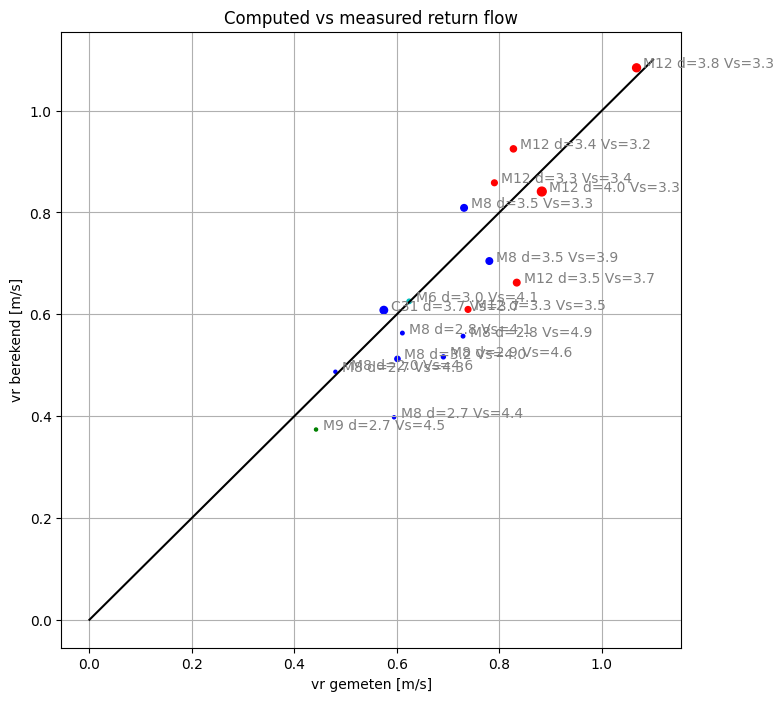

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
# ax.scatter(ships['vr'], ships['vRet2'], s= (5 * ships['vs']) ** 2, c=ships['color'])
ax.scatter(ships['vr'], ships['vr2'], s= (10 * (ships['draft']-2.0) ** 2), c=ships['color'])

for i in ships.index:
    ship = ships.loc[i]
    plt.annotate(f"{ship['type']} d={ship['draft']:.1f} Vs={ship['vs']:.1f}",
                 (ship['vr'], ship['vr2']),
    textcoords="offset points",
    color='gray',
    xytext=(5, 0),
    ha='left'
    )
    

ax.plot([0., 1.1], [0., 1.1], 'k')
ax.grid(True)
ax.set_title("Computed vs measured return flow")
ax.set_xlabel('vr gemeten [m/s]')
ax.set_ylabel('vr berekend [m/s]')

# Toename SNR (signal to noise ratio) in db als functie van de berekende retourstroom

De verwachting is dat dit de grootste correlatie oplevert.

Toename SNR = piek SNR direct na passage minus SNR voor passage.


Text(0, 0.5, 'SNR - SNR0 [dB]')

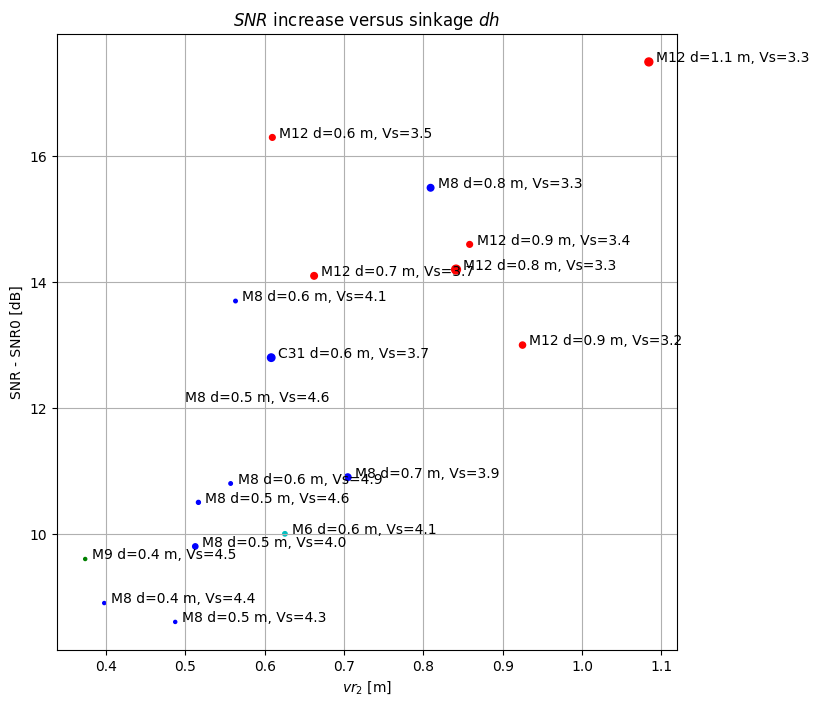

In [16]:
ships['vRet2'] = vRet(ships['vs'], -ships['dh'])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(ships['vr2'], ships['SNR'] - ships['SNR0'], s= (10 * (ships['draft']-2.0) ** 2), c=ships['color'])

for i in ships.index:
    ship = ships.loc[i]
    plt.annotate(f"{ship['type']} d={ship['vr2']:.1f} m, Vs={ship['vs']:.1f}",
                 (ship['vr2'], ship['SNR'] - ship['SNR0']),
    textcoords="offset points",
    xytext=(5, 0),
    ha='left'
    )
    
ax.grid(True)
ax.set_title(r"$SNR$ increase versus sinkage $dh$")
ax.set_xlabel(r'$vr_2$ [m]')
ax.set_ylabel('SNR - SNR0 [dB]')

# Toename van SNR versus diepgang (draft)

Hoe groter de diepgang hoe meer opwoeling?

Text(0, 0.5, 'SNR - SNR0 [dB]')

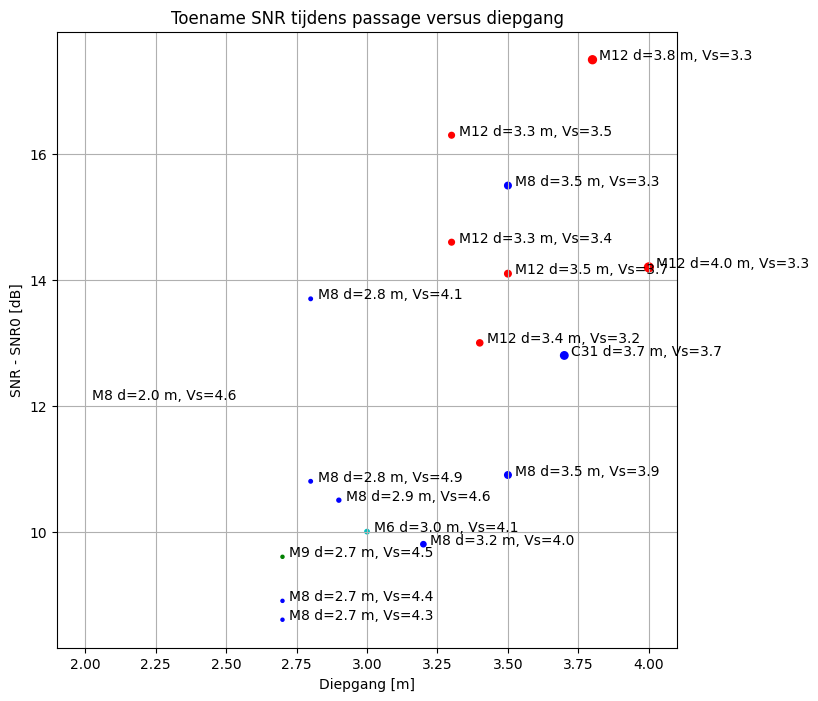

In [17]:
ships['vRet2'] = vRet(ships['vs'], -ships['dh'])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(ships['draft'], ships['SNR'] - ships['SNR0'], s= (10 * (ships['draft']-2.0) ** 2), c=ships['color'])

for i in ships.index:
    ship = ships.loc[i]
    plt.annotate(f"{ship['type']} d={ship['draft']:.1f} m, Vs={ship['vs']:.1f}",
                 (ship['draft'], ship['SNR'] - ship['SNR0']),
    textcoords="offset points",
    xytext=(5, 0),
    ha='left'
    )
    
ax.grid(True)
ax.set_title("Toename SNR tijdens passage versus diepgang")
ax.set_xlabel('Diepgang [m]')
ax.set_ylabel('SNR - SNR0 [dB]')

# Correlatie tussen de verschillende variabelen van de scheepspassage

Correlatie vs x dSNR < 0 --> Hoe sneller het schip hoe minder opwerveling.
Maar vs x draft < 0 zegt feitelijk hoe minder diepgang des te sneller vaart het schip.

De dSNR heeft wel een sterke positieve relatie met de retourstroom. Retourstroom is ook schuifspanning op de bodem gezien het uniforme verticale snelheidsprofiel beneden de grenslaag. Dus het is de retourstroom die de opwerveling veroorzaakt.

Het enige relevante voor de opwerveling is de retourstroom. dh en vr zijn uiteraard zeer sterk gecorreleerd.

De correlatie tussen dSNR en de berekende retourstroom is zelfs nog groter dan tussen de dSNR en de gemeten retourstroom.

Ergo: de uit de vs en dh berekende retourstoom is een goede predictie voor de dSNR, de opwerveling.


In [18]:
ships[['vs', 'vr', 'vr2', 'dh', 'draft', 'dSNR']].corr()


,vs,vr,vr2,dh,draft,dSNR
vs,1.000000,-0.661810,-0.823581,0.618930,-0.819528,-0.747663
vr,-0.661810,1.000000,0.874961,-0.871829,0.740182,0.709009
vr2,-0.823581,0.874961,1.000000,-0.952791,0.733435,0.750627
dh,0.618930,-0.871829,-0.952791,1.000000,-0.604002,-0.653372
draft,-0.819528,0.740182,0.733435,-0.604002,1.000000,0.580600
dSNR,-0.747663,0.709009,0.750627,-0.653372,0.580600,1.000000


# Rapport Deltares 2012, Tabel 3.1

In [19]:
ship_props = pd.DataFrame([
    [110., 11.4, 3.5, 1700., 2.0, 700., 1.2],
    [135., 17.0, 4.0, 2800., 2.3, 1000., 1.4],
    ], index=['M8', 'M12'],
    columns=['L', 'b', 'd', 'MkW', 'MDp', 'BkW', 'BDp']
)
ship_props['A'] = ship_props['b'] * ship_props['d']

simulation = pd.DataFrame(
    [[518, 'M12', 3.75, 39.9, 'M0',  3.75,  0.0,  68.0, 7.6],
     [518, 'M8',  2.75, 68.0, 'M12', 3.75, 68.0, 107.9, 4.8],
     [518, 'M12', 2.25, 68.0, 'M12', 3.25, 68.0, 136.0, 3.8]
    ], index=[1, 2, 3], columns=['Ac', 'ship1', 'As1', 'vs1', 'ship2', 'vs2', 'As2', 'As1+As2', 'Ac/(As1+As2)']
)

display(ship_props)

display(simulation)

,L,b,d,MkW,MDp,BkW,BDp,A
M8,110.0,11.4,3.5,1700.0,2.0,700.0,1.2,39.9
M12,135.0,17.0,4.0,2800.0,2.3,1000.0,1.4,68.0


,Ac,ship1,As1,vs1,ship2,vs2,As2,As1+As2,Ac/(As1+As2)
1,518,M12,3.75,39.9,M0,3.75,0.0,68.0,7.6
2,518,M8,2.75,68.0,M12,3.75,68.0,107.9,4.8
3,518,M12,2.25,68.0,M12,3.25,68.0,136.0,3.8


In [20]:
def vR(rec, verbose=False):
    """Retourstroomsnelheid berekend als blokstroom.
    
    Parameters
    ----------
    rec: pd.DataFrame record
        record with simulation properties
    verbose: bool
        whether to show iteration progress computing vr
    """
    g = 9.81
    bc = 94.0 # --- Canal width
    vs1, vs2 = rec['vs1'], rec['vs2']
    As1, As2 = rec['As1'], rec['As2']
    Ac = rec['Ac']
    for i in range(10):
        vr = (vs1 * As1 + vs2 * As2) / (Ac - (As1 + As2))
        Ac = rec['Ac'] - bc * vr ** 2 / (2 * g)
        if verbose:
            print(f"{vr:5.3f} m/s, {vr**2/(2*g):4.2f} m")
    return vr

for idx in simulation.index:
    vr = vR(simulation.loc[idx], False)
    print(f"vr = {vr:.2f} m/s")

vr = 0.29 m/s
vr = 1.00 m/s
vr = 0.84 m/s


# Bottom elevation profiles

Data for yRD 475500 were saved to a geopackage from the elevation profile window in QGIS. That file
contains the data for all available bathymeties for that line. It is loaded into a geodataframe,
and the data for each available year are stored in a new ordinary pd.DataFrame with the elevations
in the columns with header equal to the year it represesnts. The x-values (distance) from the left
point of the cross section line (on the left (west) shore of the canal) is used as index.

This allows plotting the elevationsn for each available year and see the differences.
In a second step, the yearly data are stored in a float array to take the maximim
minimum and std over all years at each x.


In [80]:
profs = gp.read_file(os.path.join(dirs.geo, "BodemProfiel_475500.gpkg"))
profs['year'] = [int(p[:4]) for p in profs['layer'].values]
prof = profs[profs['year']==profs['year'][0]]

Image saved as /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/images/bodemARK2011-25_y475500.pdf


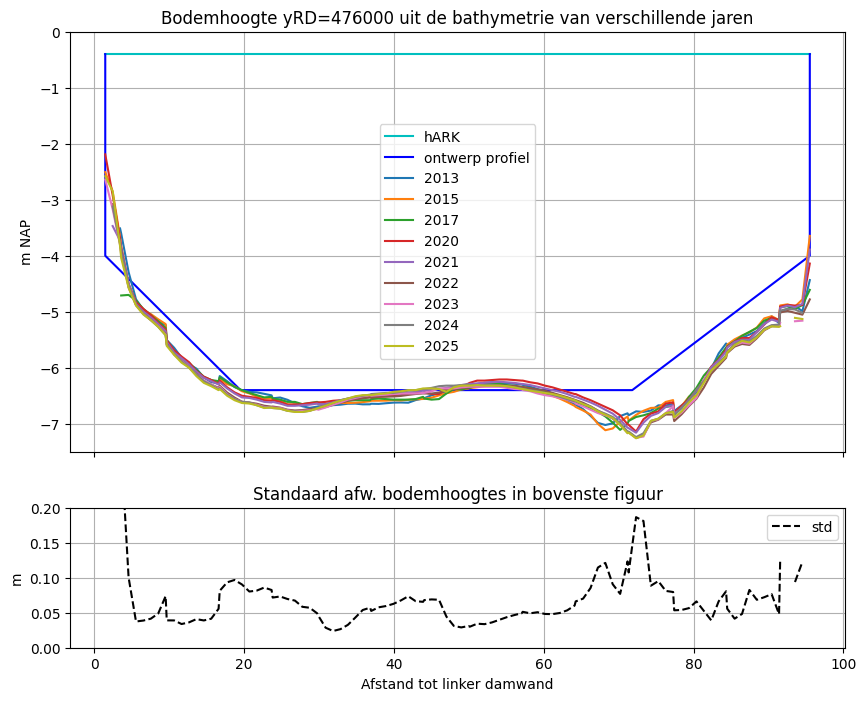

In [92]:
# --- to set up a DataFrame with one col per year start with the first year
prof = profs[profs['year']==profs['year'][0]][['distance', 'elevation']]

# --- Use colun distance as index
prof.index = prof['distance']

# --- Get the available years in the geopackage
years = np.unique(profs['year'])

# ---- Generate the year columns
for y in years:
    prof[y] =profs.loc[profs['year']==y, 'elevation'].values
prof = prof.drop(['distance', 'elevation'], axis=1)
prof = prof[(prof.index > 0) & (prof.index < 96)]

# --- Generate a float array with the year columns as values
Yarr = np.zeros((len(prof), len(prof.columns)))
Xarr = np.asarray(prof.index)
for i, col in enumerate(prof.columns):
    Yarr[:, i] = prof[col]

# --- Compute statistics over the years for each x
prof['min'] = Yarr.min(axis=1)
prof['max'] = Yarr.max(axis=1)
prof['std'] = Yarr.std(axis=1)

# --- Plot the elevations and the std along x.
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": [3, 1]}, figsize=(10, 8))

# -- standaard profiel
x0, x1, b, hARK = Xarr[1], Xarr[-1], Xarr[-1] - Xarr[1], -0.4

ax1.plot([Xarr[1], Xarr[-1]], [hARK, hARK], 'c', label='hARK')

xsp = np.array([ 0.0,  0.0, 19.2, 74.8, 100., 100.]) * b / 100. + x0
ysp = np.array([-0.0, -3.6, -6.0, -6.0, -3.6, -0.0]) + hARK
ax1.plot(xsp, ysp, 'b', label='ontwerp profiel')

for y in years:
    ax1.plot(prof.index, prof[y], label=f"{y}")

# ax.plot(prof.index, prof['max'], 'k--', label='max')
# ax.plot(prof.index, prof['min'], 'm--', label='min')

ax1.set_title('Bodemhoogte yRD=476000 uit de bathymetrie van verschillende jaren')
ax1.set_ylabel('m NAP')
ax1.set_ylim(-7.5, 0)
ax1.grid(True)
ax1.legend()

# -- Plot the std for each x.
ax2.plot(prof.index, prof['std'], 'k--', label='std')
ax2.set_ylim(0, 0.2)

ax2.set_title('Standaard afw. bodemhoogtes in bovenste figuur')
ax2.set_xlabel('Afstand tot linker damwand')
ax2.set_ylabel('m')
ax2.grid(True)
ax2.legend()

fname = "bodemARK2011-25_y475500.pdf"
fig.savefig(os.path.join(dirs.images, fname))
print(f"Image saved as {os.path.join(dirs.images, fname)}")
    

In [83]:
prof.index

Index([0.4767880320186945, 1.4657920788753314, 2.4547961257319684,
       3.4438001725886047, 3.5916886281934803,  4.580692675050117,
        5.569696721906754,  6.558700768763392,  7.547704815620028,
        8.536708862476665,
       ...
        87.45368598455286,   88.4426900314095,  89.43169407826613,
        90.42069812512277,   91.4097021719794,  91.55759062758428,
        92.54659467444091,  93.53559872129756,   94.5246027681542,
        95.51360681501083],
      dtype='float64', name='distance', length=109)